Showing da black hole with visible rays and intensity...


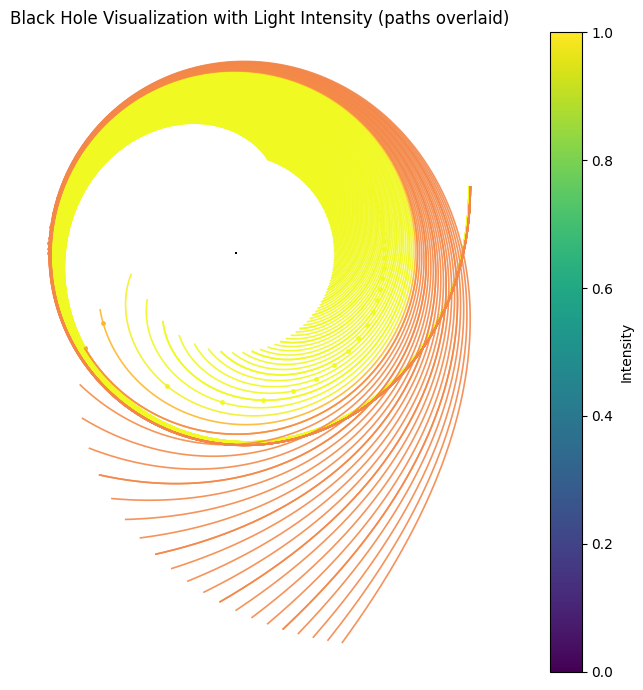

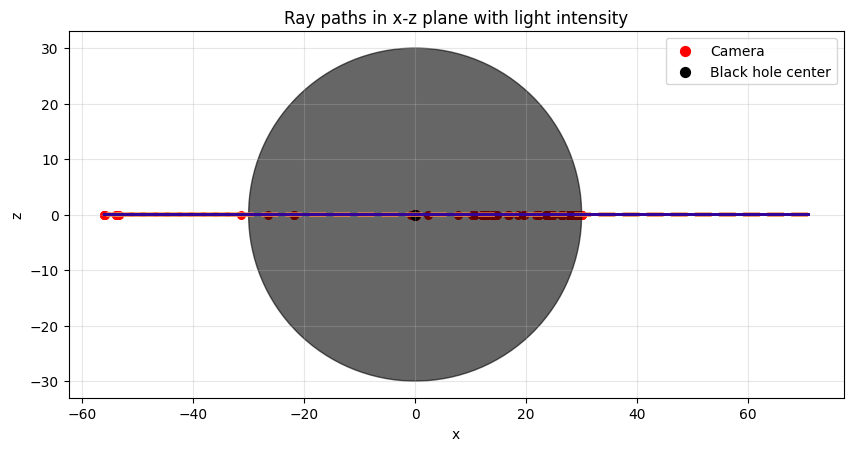

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import constants
from scipy.ndimage import gaussian_filter
import gc

# 175x175 pixels til visualisering og udregninger.
width = 175
height = 175

# Simpelt sort hul. Pixels bliver mørke når de er tæt på midten.
Event_horizon = 30.0

# Position af sort hul og "kamera"
kamera_pos = np.array([0.0, 200.0, 0.0])
black_hole_pos = np.array([0.0, 0.0, 0.0])

# Gem baggrund så den kun skal laves en gang
star_directions = None
image_plane_distance = 100.0
scale = 0.2
bh_mass = 55.0
dt = 0.1
max_steps = 5200

def generate_star_directions():
    global star_directions
    if star_directions is not None:
        return
    num_stars = 320
    star_theta = np.random.uniform(0, 2*np.pi, num_stars)
    star_phi = np.random.uniform(0, np.pi, num_stars)
    star_directions = np.array([
        np.sin(star_phi) * np.cos(star_theta),
        np.sin(star_phi) * np.sin(star_theta),
        np.cos(star_phi)
    ]).T


def trace_ray(x, y, record_path=False, emitter='top_parallel'):
    generate_star_directions()
    px = (x / width * 2 - 1) * scale
    py = (y / height * 2 - 1) * scale

    # Determine emitter position and ray direction
    if emitter == 'camera':
        emitter_pos = kamera_pos
        image_point = emitter_pos + np.array([px, py, image_plane_distance])
        ray_dir = image_point - emitter_pos
        ray_dir = ray_dir / np.linalg.norm(ray_dir)
    elif emitter == 'top':
        emitter_pos = np.array([0.0, 500.0, 0.0])
        image_point = emitter_pos + np.array([px, -image_plane_distance, py])
        ray_dir = image_point - emitter_pos
        ray_dir = ray_dir / np.linalg.norm(ray_dir)
    elif emitter == 'right_parallel':
        # Parallel rays from the right, all traveling in -x direction
        py_start = (y / height * 2 - 1) * scale
        pz_start = (x / width * 2 - 1) * scale
        ray_pos = np.array([700.0, py_start, pz_start + 615.0])
        ray_dir = np.array([-1.0, 0.0, 0.0])
    elif emitter == 'top_parallel':
        # Parallel rays from above, all traveling in -y direction
        px_start = (x / width * 2 - 1) * scale
        pz_start = (y / height * 2 - 1) * scale
        ray_pos = np.array([px_start + 70.65, 20.0, pz_start])
        ray_dir = np.array([0.0, -1.0, 0.0])
    else:
        emitter_pos = kamera_pos
        image_point = emitter_pos + np.array([px, py, image_plane_distance])
        ray_dir = image_point - emitter_pos
        ray_dir = ray_dir / np.linalg.norm(ray_dir)

    if emitter not in ('right_parallel', 'top_parallel'):
        ray_pos = emitter_pos.copy()
    
    path = [ray_pos.copy()] if record_path else None
    min_distance = np.inf

    for _ in range(max_steps):
        diff = black_hole_pos - ray_pos
        distance = np.linalg.norm(diff)
        min_distance = min(min_distance, distance)
        if distance < Event_horizon:
            if record_path:
                path.append(ray_pos.copy())
                return 0.0, np.array(path)
            return 0.0

        if distance > 0.1:
            direction_to_bh = diff / distance
            gravity_strength = bh_mass / distance**2
            acceleration = direction_to_bh * gravity_strength * dt
            ray_dir += acceleration
            ray_dir /= np.linalg.norm(ray_dir)

        ray_pos += ray_dir * dt
        if record_path:
            path.append(ray_pos.copy())

        if np.linalg.norm(ray_pos) > 4000:
            max_dot = np.max(np.dot(star_directions, ray_dir))
            star_intensity = 1.0 if max_dot > 0.999 else 0.05
            glow = np.exp(-0.15 * max(0.0, min_distance - Event_horizon))
            intensity = max(star_intensity, 0.05 + 0.9 * glow)
            if record_path:
                return intensity, np.array(path)
            return intensity

    glow = np.exp(-0.15 * max(0.0, min_distance - Event_horizon))
    intensity = 0.05 + 0.9 * glow
    if record_path:
        return intensity, np.array(path)
    return intensity


def render(num_samples=500, emitter='camera'):
    image = np.zeros((height, width), dtype=float)
    center_y, center_x = height // 2, width // 2
    max_trace_radius = Event_horizon * 3.0

#loader kun nogen pixels så den loader meget hurtigere
    y_coords, x_coords = np.where(
        np.hypot(np.arange(height)[:, None] - center_y,
                 np.arange(width)[None, :] - center_x) <= max_trace_radius,
    )
    num_samples = min(num_samples, len(x_coords))
    sample_indices = np.random.choice(len(x_coords), size=num_samples, replace=False)

    for idx in sample_indices:
        y = y_coords[idx]
        x = x_coords[idx]
        image[y, x] = trace_ray(x, y, emitter=emitter)
    return image


def sample_ray_paths(emitter='top_parallel'):
    sample_x = np.linspace(0, width - 1, 220, dtype=int)
    sample_y = np.full_like(sample_x, height // 2)
    paths = []
    for x, y in zip(sample_x, sample_y):
        intensity, path = trace_ray(x, y, record_path=True, emitter=emitter)
        paths.append((path, intensity))
    return paths

# da black hole
# Vi vil sætte det sorte hul ved koordinaterne (0,0,0) og kameraet ved (0,0,-500) så vi kigger på det sorte hul

if __name__ == "__main__":
    print("Showing da black hole with visible rays and intensity...")

    # Udsendingsområde er ens for udregning og render.
    emitter_choice = 'top_parallel'  # 'camera', 'top_parallel', or 'right_parallel'
    image = render(num_samples=500, emitter=emitter_choice)
    ray_paths = sample_ray_paths(emitter=emitter_choice)

    # Image with ray paths overlaid (project world x,y to image pixels)
    plt.figure(figsize=(12, 7))
    plt.imshow(image, cmap='inferno', vmin=0, vmax=1, origin='lower')

    for path, intensity in ray_paths:
        # path is array of 3D positions (x, y, z)
        px_world = path[:, 0]
        py_world = path[:, 1]
        pixel_x = (px_world / scale + 1.0) / 2.0 * (width - 1)
        pixel_y = (py_world / scale + 1.0) / 2.0 * (height - 1)

        # color by intensity / proximity (brighter if closer)
        min_dist = np.min(np.linalg.norm(path - black_hole_pos, axis=1))
        color_val = np.clip(1.0 - (min_dist - Event_horizon) / (Event_horizon * 3.0), 0.0, 1.0)
        color = plt.cm.plasma(color_val)

        plt.plot(pixel_x, pixel_y, color=color, linewidth=1.2, alpha=0.9)

        # mark the first close approach (first "glow") on the image overlay
        dists = np.linalg.norm(path - black_hole_pos, axis=1)
        glow_idx = np.where(dists <= (Event_horizon * 1.5))[0]
        if glow_idx.size > 0:
            first_idx = glow_idx[0]
        else:
            first_idx = int(np.argmin(dists))
        px_g = (path[first_idx, 0] / scale + 1.0) / 2.0 * (width - 1)
        py_g = (path[first_idx, 1] / scale + 1.0) / 2.0 * (height - 1)
        plt.scatter([px_g], [py_g], color=color, s=20, edgecolor='white')

    plt.title("Black Hole Visualization with Light Intensity (paths overlaid)")
    plt.axis('off')
    plt.colorbar(label='Intensity')
    plt.tight_layout()
    plt.show()
    plt.close()

    # Also plot x-z plane for path geometry, color by proximity and annotate orbits
    plt.figure(figsize=(10, 6))
    for path, intensity in ray_paths:
        color_val = np.clip(intensity, 0.0, 1.0)
        color = plt.cm.plasma(color_val)
        linewidth = 1.5 + 2.5 * intensity

        # detect orbiting: total angular sweep around BH in x-z plane
        angles = np.unwrap(np.arctan2(path[:, 2], path[:, 0]))
        total_sweep = angles[-1] - angles[0]
        orbiting = abs(total_sweep) > (2 * np.pi * 0.8)

        if orbiting:
            plt.plot(path[:, 0], path[:, 2], color=color, alpha=0.95, linewidth=linewidth, linestyle='--')
            # mark orbit with a thicker red marker at closest approach
            dists = np.linalg.norm(path - black_hole_pos, axis=1)
            close_idx = int(np.argmin(dists))
            plt.scatter([path[close_idx, 0]], [path[close_idx, 2]], color='red', s=30)
        else:
            plt.plot(path[:, 0], path[:, 2], color=color, alpha=0.9, linewidth=linewidth)

    horizon = plt.Circle((0, 0), Event_horizon, color='black', alpha=0.6)
    plt.gca().add_patch(horizon)
    plt.scatter([kamera_pos[0]], [kamera_pos[2]], color='red', s=50, label='Camera')
    plt.scatter([0], [0], color='black', s=50, label='Black hole center')
    plt.xlabel('x')
    plt.ylabel('z')
    plt.title('Ray paths in x-z plane with light intensity')
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, alpha=0.3)
    plt.show()
    plt.close()

    # Clean up large variables so repeated runs don't accumulate memory and slow
    try:
        del image
        del ray_paths
    except NameError:
        pass
    plt.close('all')
    gc.collect()
